In [56]:
import pandas as pd
import numpy as np


In [57]:
import pandas as pd

df = pd.read_csv('spam.csv', encoding='latin-1')

df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [58]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4387,ham,"see you then, we're all christmassy here!",NaN,NaN,NaN
2691,ham,Hey tmr meet at bugis 930 ?,NaN,NaN,NaN
2165,ham,I'm not coming home 4 dinner.,NaN,NaN,NaN
2732,ham,How dare you stupid. I wont tell anything to y...,NaN,NaN,NaN
5435,ham,I'm wif him now buying tix lar...,NaN,NaN,NaN


In [59]:
df.shape

(5572, 5)

Steps to do:

1. Data Cleaning
2. EDA
3. Text Preprocessing
4. Model Building
5. Evaluation
6. Improvement
7. Website
8. Deploy

## 1. Data Cleaning

In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [61]:
## Drop last three columns

df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)
##permanent operation so we use inplace = True

In [62]:
df.sample(5)

,v1,v2
4771,ham,"Hi, Mobile no. &lt;#&gt; has added you in th..."
2859,ham,I want to be there so i can kiss you and feel ...
5079,ham,\Keep ur problems in ur heart
2318,ham,On the way to office da..
3422,spam,Had your mobile 10 mths? Update to latest Oran...


In [63]:
## Renaming the columns
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)
df.sample(5)

,target,text
5117,ham,Aslamalaikkum....insha allah tohar beeen muht ...
1915,ham,Its not that time of the month nor mid of the ...
2787,ham,"Forgot it takes me 3 years to shower, sorry. W..."
3307,ham,But i'm surprised she still can guess right lo...
812,spam,Congratulations ur awarded either å£500 of CD ...


Applying LabelEncoder

In [64]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

In [65]:
encoder.fit_transform(df['target'])   # applying label encoder on target column

array([0, 0, 1, ..., 0, 0, 0])

In [66]:
df['target'] = encoder.fit_transform(df['target'])  # reassigned the values of the target column in 0 or 1 form

In [67]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [68]:
# checking missing values
df.isnull().sum()

,0
target,0
text,0


In [69]:
## Check for duplicated values
df.duplicated().sum()

np.int64(403)

In [70]:
## Remove duplicates

df = df.drop_duplicates(keep='first')

In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df.shape

(5169, 2)

## 2. EDA

In [73]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [74]:
df['target'].value_counts()   # it gives data distribution

,count
target,
0,4516
1,653


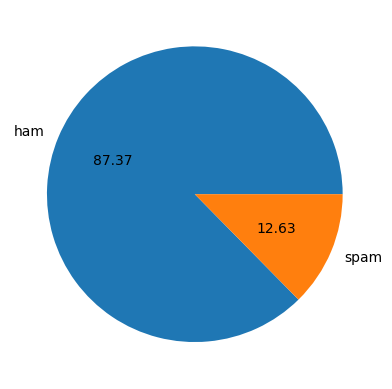

In [75]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(), labels=['ham', 'spam'], autopct="%0.2f")
plt.show()

Data is imbalanced

ham = 87.37

spam = 12.63

In [76]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [77]:
df['text'].apply(len)    # gives  total no of characters in a sentence

,text
0,111
1,29
2,155
3,49
4,61
...,...
5567,161
5568,37
5569,57
5570,125


In [78]:
# now put it into the new  column

df['num_characters'] = df['text'].apply(len)

In [79]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [80]:
## fetch num of words
df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

,text
0,24
1,8
2,37
3,13
4,15
...,...
5567,35
5568,9
5569,15
5570,27


In [81]:
# store the num of words in new column
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [82]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [83]:
# now for the number of sentences
df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

,text
0,2
1,2
2,2
3,1
4,1
...,...
5567,4
5568,1
5569,2
5570,1


In [84]:
# creating new column which stores num_sentences
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [85]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [86]:
df[['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [87]:
# classify ham messeges
df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [88]:
# classiffy spam messeges
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [89]:
import seaborn as sns


<Axes: xlabel='num_characters', ylabel='Count'>

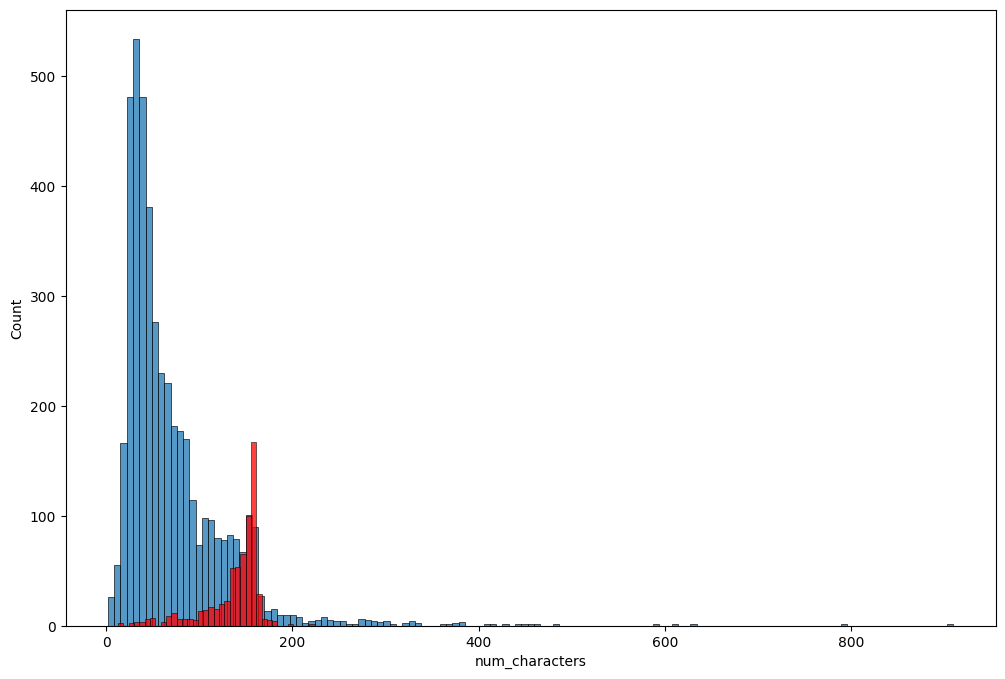

In [90]:
# for number of characters

plt.figure(figsize=(12,8))

sns.histplot(df[df['target'] == 0]['num_characters'])   # for spam
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')   # for ham not spam

<Axes: xlabel='num_words', ylabel='Count'>

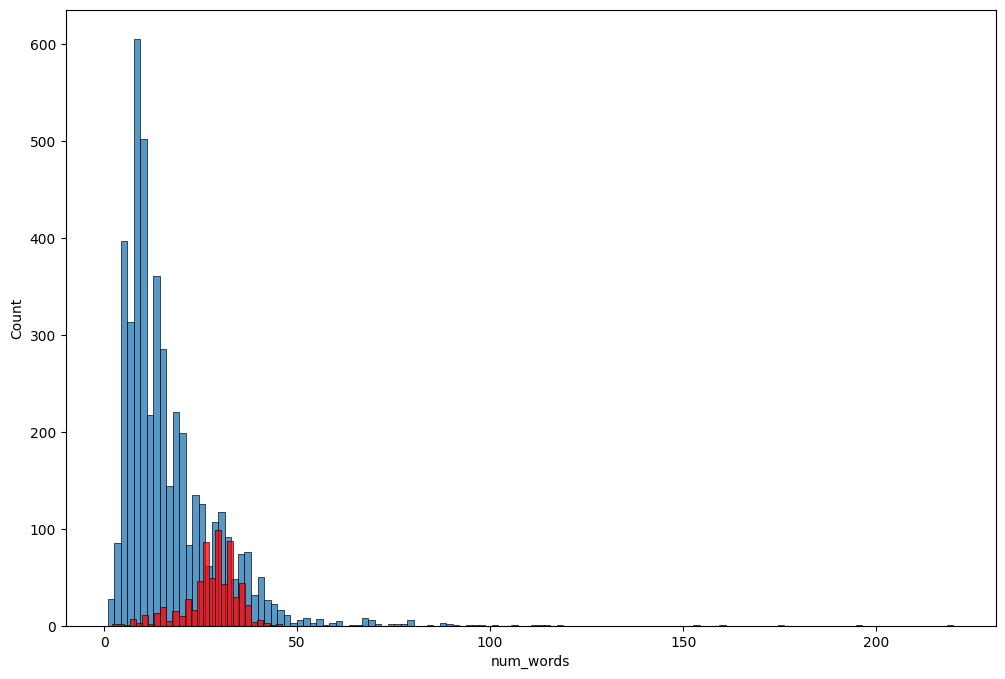

In [91]:
# for number of words

plt.figure(figsize=(12,8))

sns.histplot(df[df['target'] == 0]['num_words'])   # for spam
sns.histplot(df[df['target'] == 1]['num_words'], color='red')   # for ham not spam

<Axes: xlabel='num_sentences', ylabel='Count'>

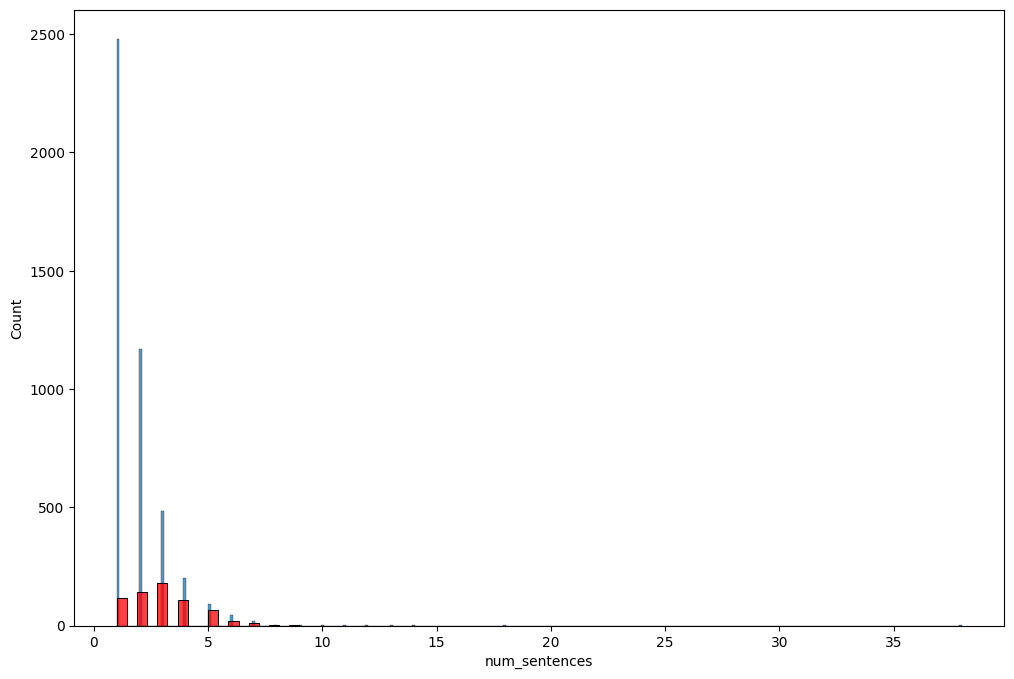

In [92]:
# for number of sentences

plt.figure(figsize=(12,8))

sns.histplot(df[df['target'] == 0]['num_sentences'])   # for spam
sns.histplot(df[df['target'] == 1]['num_sentences'], color='red')   # for ham not spam

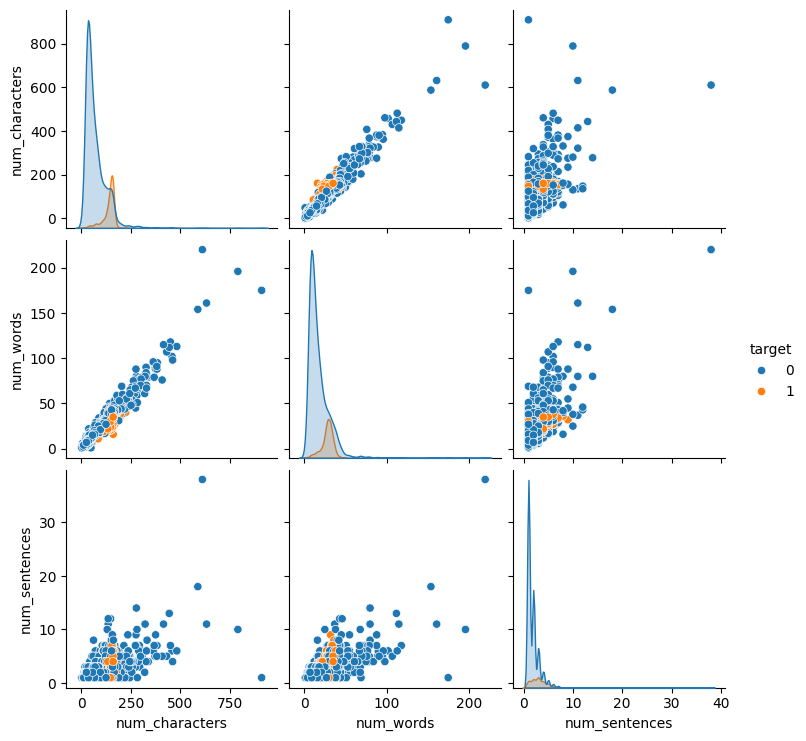

In [93]:
sns.pairplot(df, hue='target')

<Axes: >

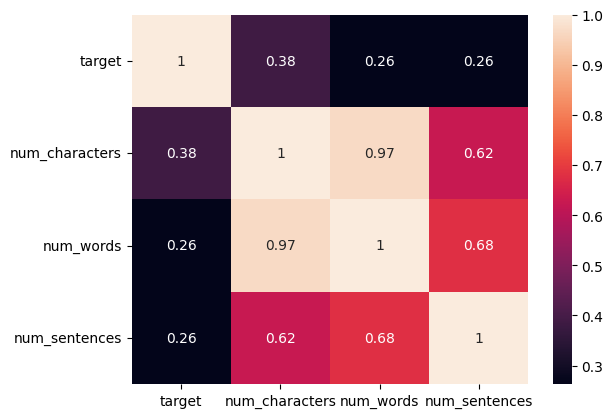

In [94]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## 3. Data Preprocessing
*   Lower case
*   Tokenization
*   Removing Special Characters
*   Removing StopWords and Punctuation
*   Stemming








In [95]:
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
import nltk
import string
nltk.download('stopwords')

def transform_text(text):

    text = text.lower()  # convert into lowercase
    text = nltk.word_tokenize(text)

    y = []

    # Removing special characters
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    # Removing stopwords and punctuations
    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    # Stemming
    ps = PorterStemmer()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [96]:
df['transformed_text'] = df['text'].apply(transform_text)   # assigned the output into new column

In [97]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


Generating Wordcloud for Spam Messeges

In [98]:
from wordcloud import WordCloud
wc = WordCloud(width=500, height=500, min_font_size=10, background_color='white')

In [99]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

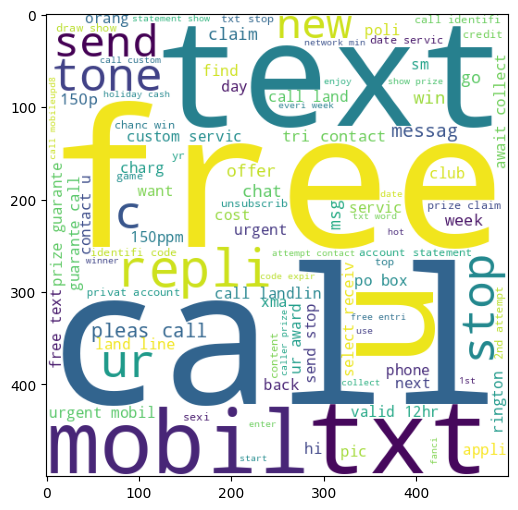

In [100]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

Generating Word Cloud for Ham Messeges

In [101]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

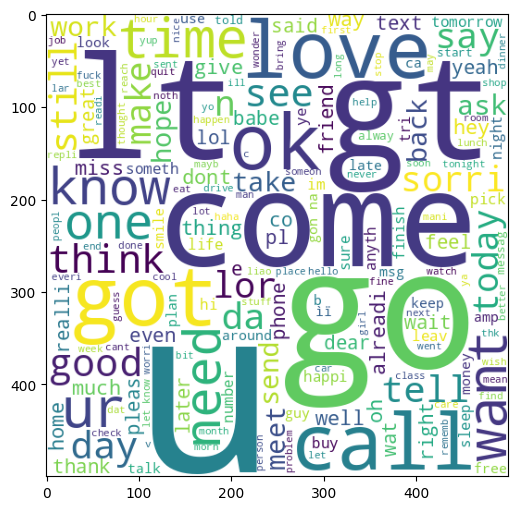

In [102]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

For the Spam

In [103]:
spam_corpus = []

for msg in df[df['target'] == 1]['transformed_text'].tolist():
  for word in msg.split():
    spam_corpus.append(word)

In [104]:
len(spam_corpus)

9939

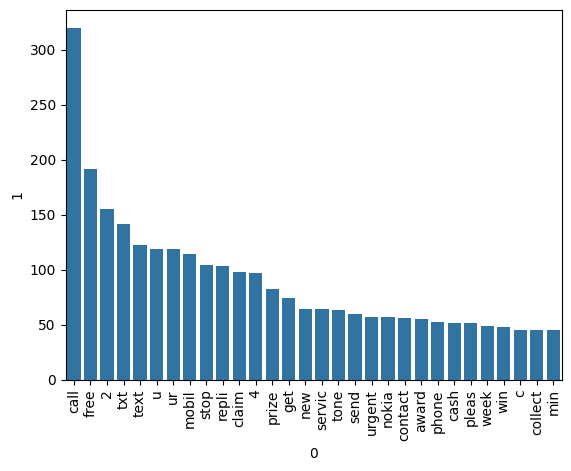

In [105]:
from collections import Counter


common_words = pd.DataFrame(
    Counter(spam_corpus).most_common(30)
)

sns.barplot(
    data=common_words,    # gives most common frequent 30 words in spam messeges
    x=0,
    y=1
)

plt.xticks(rotation='vertical')
plt.show()

For the Ham messeges

In [106]:
ham_corpus = []

for msg in df[df['target'] == 0]['transformed_text'].tolist():
  for word in msg.split():
    ham_corpus.append(word)

In [107]:
len(ham_corpus)

35404

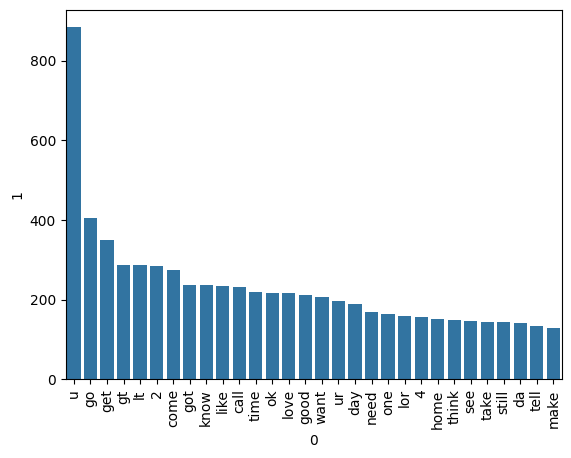

In [108]:
from collections import Counter


common_words = pd.DataFrame(
    Counter(ham_corpus).most_common(30)
)

sns.barplot(
    data=common_words,    # gives most common frequent 30 words in ham messege
    x=0,
    y=1
)

plt.xticks(rotation='vertical')
plt.show()

## 4. Model Building
Naive Bayes = Best for textual data

In [109]:
# Text Vectorization
# using Bag of Words

In [110]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()


In [111]:
X = cv.fit_transform(df['transformed_text']).toarray()

In [112]:
X.shape

(5169, 6708)

In [113]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [114]:
from sklearn.model_selection import train_test_split

X_tain, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
#Training and testing



# Importing all the naive algorithm


In [115]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()


# Training gaussian naive bayes algorithm

gnb.fit(X_tain, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315


In [116]:
# Training multinominal naive bayes algorithm
mnb.fit(X_tain, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [117]:
# Training bernoulli naive bayes algorithm
bnb.fit(X_tain, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


By using TF-IDF

In [118]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
tfidf = TfidfVectorizer(max_features = 3000)
cv = CountVectorizer()


In [119]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [120]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [121]:
X.shape

(5169, 3000)

In [122]:
y = df['target'].values
y

array([0, 0, 1, ..., 0, 0, 0])

In [123]:
from sklearn.model_selection import train_test_split

X_tain, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
#Training and testing



In [124]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score


gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()




In [125]:
# Training gaussian naive bayes algorithm

gnb.fit(X_tain, y_train)
y_pred1 = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred1))
print(confusion_matrix(y_test,y_pred1))
print(precision_score(y_test,y_pred1))

0.8762088974854932
[[784 112]
 [ 16 122]]
0.5213675213675214


In [126]:
# Training multinominal naive bayes algorithm
mnb.fit(X_tain, y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9787234042553191
[[889   7]
 [ 15 123]]
0.9461538461538461


In [127]:
# Training bernoulli naive bayes algorithm
bnb.fit(X_tain, y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9835589941972921
[[895   1]
 [ 16 122]]
0.991869918699187


WE keep tfidf with multinominal naive bayes

## Training all the Machine Learning Models

In [128]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

In [129]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)

In [130]:
 # importing all the models

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [131]:
svc = SVC(kernel='sigmoid', gamma=1.0)

knc = KNeighborsClassifier()

mnb = MultinomialNB()

dtc = DecisionTreeClassifier(max_depth=5)

lrc = LogisticRegression(solver='liblinear', penalty='l1')

rfc = RandomForestClassifier(
    n_estimators=50,
    random_state=2
)

abc = AdaBoostClassifier(
    n_estimators=50,
    random_state=2
)

bc = BaggingClassifier(
    n_estimators=50,
    random_state=2
)

etc = ExtraTreesClassifier(
    n_estimators=50,
    random_state=2
)

gbdt = GradientBoostingClassifier(
    n_estimators=50,
    random_state=2
)

xgb = XGBClassifier(
    n_estimators=50,
    random_state=2
)

In [132]:
classifiers = {
    'SVC': svc,
    'KN': knc,      # creating the dictionary with keeping all the key pairs
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT': gbdt,
    'xgb': xgb
}

In [133]:
from sklearn.metrics import accuracy_score, precision_score

def train_classifier(clf, X_train, y_train, X_test, y_test):

    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    return accuracy, precision

In [134]:
train_classifier(svc, X_train, y_train, X_test, y_test)

(0.9758220502901354, 0.9747899159663865)

In [135]:
# Run all the algrithmn through the loop
accuracy_scores = []
precision_scores = []

for name, clf in classifiers.items():

    current_accuracy, current_precision = train_classifier(
        clf,
        X_train,
        y_train,
        X_test,
        y_test
    )

    print("For", name)
    print("Accuracy:", current_accuracy)
    print("Precision:", current_precision)
    print()

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For SVC
Accuracy: 0.9758220502901354
Precision: 0.9747899159663865

For KN
Accuracy: 0.9052224371373307
Precision: 1.0

For NB
Accuracy: 0.9709864603481625
Precision: 1.0

For DT
Accuracy: 0.9332688588007737
Precision: 0.8415841584158416

For LR
Accuracy: 0.9555125725338491
Precision: 0.96

For RF
Accuracy: 0.9738878143133463
Precision: 0.9826086956521739

For AdaBoost
Accuracy: 0.9216634429400387
Precision: 0.8202247191011236

For BgC
Accuracy: 0.9584139264990329
Precision: 0.8682170542635659

For ETC
Accuracy: 0.9748549323017408
Precision: 0.9745762711864406

For GBDT
Accuracy: 0.9506769825918762
Precision: 0.9306930693069307

For xgb
Accuracy: 0.9700193423597679
Precision: 0.9572649572649573



In [136]:
# Results DataFrame
performance_df = pd.DataFrame({
    'Algorithm': classifiers.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.975822,0.974790
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
3,DT,0.933269,0.841584
4,LR,0.955513,0.960000
5,RF,0.973888,0.982609
6,AdaBoost,0.921663,0.820225
7,BgC,0.958414,0.868217
8,ETC,0.974855,0.974576
9,GBDT,0.950677,0.930693


In [137]:
# for getting best model details
performance_df.sort_values(
    by='Precision',      # it gives result according to the precision
    ascending=False
)

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.970019,0.957265
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.933269,0.841584


In [138]:
performance_df1 = pd.melt(
    performance_df,
    id_vars='Algorithm',
    value_vars=['Accuracy', 'Precision']
)

In [139]:
performance_df1

,Algorithm,variable,value
0,SVC,Accuracy,0.975822
1,KN,Accuracy,0.905222
2,NB,Accuracy,0.970986
3,DT,Accuracy,0.933269
4,LR,Accuracy,0.955513
5,RF,Accuracy,0.973888
6,AdaBoost,Accuracy,0.921663
7,BgC,Accuracy,0.958414
8,ETC,Accuracy,0.974855
9,GBDT,Accuracy,0.950677


<function matplotlib.pyplot.show(close=None, block=None)>

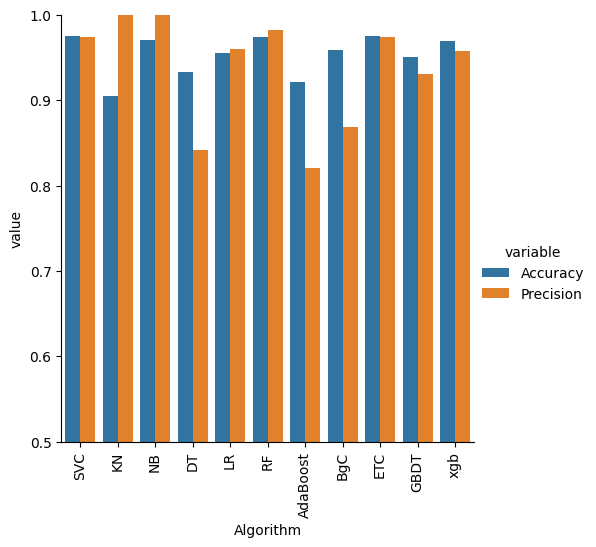

In [140]:
sns.catplot(x = 'Algorithm',y='value',hue='variable',data=performance_df1,kind='bar',height=5)

plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show

# Model Improve

1. Change the Max_features paramer of TfIdf

In [141]:
temp_df = pd.DataFrame({
    'Algorithm': classifiers.keys(),
    'Accuracy_max_ft_3000': accuracy_scores,
    'Precision_max_ft_3000': precision_scores
})

temp_df

,Algorithm,Accuracy_max_ft_3000,Precision_max_ft_3000
0,SVC,0.975822,0.974790
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
3,DT,0.933269,0.841584
4,LR,0.955513,0.960000
5,RF,0.973888,0.982609
6,AdaBoost,0.921663,0.820225
7,BgC,0.958414,0.868217
8,ETC,0.974855,0.974576
9,GBDT,0.950677,0.930693


In [142]:
performance_df = pd.merge(
    performance_df,
    temp_df,
    on='Algorithm'
)

In [143]:
new_df = performance_df.merge(temp_df,on='Algorithm')
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

new_df_scaled

,Algorithm,Accuracy,Precision,Accuracy_max_ft_3000_x,Precision_max_ft_3000_x,Accuracy_max_ft_3000_y,Precision_max_ft_3000_y,Accuracy_max_ft_3000,Precision_max_ft_3000
0,SVC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
1,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
2,NB,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000,0.970986,1.000000
3,DT,0.933269,0.841584,0.933269,0.841584,0.933269,0.841584,0.933269,0.841584
4,LR,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000
5,RF,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609,0.973888,0.982609
6,AdaBoost,0.921663,0.820225,0.921663,0.820225,0.921663,0.820225,0.921663,0.820225
7,BgC,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217,0.958414,0.868217
8,ETC,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576,0.974855,0.974576
9,GBDT,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693,0.950677,0.930693


Append the extra column (number_of_characters)  in my input then re run it

In [144]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [145]:
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

In [146]:
X = np.hstack((X,df['num_characters'].values.reshape(-1,1)))

# appending the num_character column  to X(input_features)

In [147]:
X.shape

(5169, 3001)

In [148]:
y = df['target'].values

In [149]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)
#

In [150]:
# Results DataFrame
performance_df = pd.DataFrame({
    'Algorithm': classifiers.keys(),
    'Accuracy': accuracy_scores,
    'Precision': precision_scores
})

performance_df

,Algorithm,Accuracy,Precision
0,SVC,0.975822,0.974790
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
3,DT,0.933269,0.841584
4,LR,0.955513,0.960000
5,RF,0.973888,0.982609
6,AdaBoost,0.921663,0.820225
7,BgC,0.958414,0.868217
8,ETC,0.974855,0.974576
9,GBDT,0.950677,0.930693


In [151]:
# for getting best model details
performance_df.sort_values(
    by='Precision',      # it gives result according to the precision
    ascending=False
)

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.970986,1.000000
5,RF,0.973888,0.982609
0,SVC,0.975822,0.974790
8,ETC,0.974855,0.974576
4,LR,0.955513,0.960000
10,xgb,0.970019,0.957265
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.933269,0.841584


In [152]:
# Voting Classifier

svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('svm', svc),
        ('nb', mnb),
        ('etc', etc)
    ],
    voting='soft'
)

# Train
voting.fit(X_train, y_train)

# Prediction
y_pred = voting.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Accuracy: 0.9429400386847195
Precision: 1.0


In [153]:
# Applying Stacking
estimators = [('svm',svc),('nb',mnb),('et',etc)]
final_estimator = RandomForestClassifier()

In [154]:
from sklearn.ensemble import StackingClassifier

clf = StackingClassifier(
    estimators=estimators,
    final_estimator=final_estimator
)

In [155]:
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

Accuracy: 0.9787234042553191
Precision: 0.9461538461538461


In [156]:
# Re-create and explicitly fit the vectorizer + model before saving
# (Fixes bug: previously mnb was re-instantiated for VotingClassifier in the cell above,
# and VotingClassifier.fit() only fits INTERNAL CLONES of mnb, not the mnb object itself,
# so the pickled model was unfitted.)

tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

mnb = MultinomialNB()
mnb.fit(X, y)  # fit directly on the full data before saving

import pickle
pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))
pickle.dump(mnb, open('model.pkl', 'wb'))

print('Saved vectorizer.pkl and model.pkl -- model is fitted:', hasattr(mnb, "classes_"))

Saved vectorizer.pkl and model.pkl -- model is fitted: True
